In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('HouseData.csv')

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [6]:
df.shape

(1460, 81)

In [7]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
(df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)

PoolQC           0.995205
MiscFeature      0.963014
Alley            0.937671
Fence            0.807534
MasVnrType       0.597260
                   ...   
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
SalePrice        0.000000
Length: 81, dtype: float64

In [10]:
(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [11]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [12]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
for col,val in df.isnull().sum().items():
    if val > 0 :
        print(f"{col}:{val}")

LotFrontage:259
Alley:1369
MasVnrType:872
MasVnrArea:8
BsmtQual:37
BsmtCond:37
BsmtExposure:38
BsmtFinType1:37
BsmtFinType2:38
Electrical:1
FireplaceQu:690
GarageType:81
GarageYrBlt:81
GarageFinish:81
GarageQual:81
GarageCond:81
PoolQC:1453
Fence:1179
MiscFeature:1406


In [14]:
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [15]:
df=df.drop(columns=['Alley'])

In [16]:
df=df.drop(columns=['PoolQC'])

In [17]:
df=df.drop(columns=['Fence'])

In [18]:
df=df.drop(columns=['MiscFeature'])

In [19]:
df=df.dropna(subset=['Electrical'])

In [20]:
df=df.dropna(subset=['MasVnrType'])

In [21]:
df['MasVnrArea']=df['MasVnrArea'].fillna(df['MasVnrArea'].mean())

In [22]:
df=df.drop(columns=['FireplaceQu'])

In [23]:
df=df.dropna(subset=['BsmtQual'])

In [24]:
df=df.dropna(subset=['BsmtCond'])

In [25]:
df=df.dropna(subset=['BsmtExposure'])

In [26]:
df=df.dropna(subset=['BsmtFinType1'])


In [27]:
df=df.dropna(subset=['BsmtFinType2'])

In [28]:
df=df.dropna(subset=['GarageYrBlt'])

In [29]:
df=df.dropna(subset=['GarageFinish'])

In [30]:
df=df.dropna(subset=['GarageCond'])

In [31]:
df=df.dropna(subset=['GarageQual'])

In [32]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000000,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
2,3,60,RL,68.000000,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
4,5,60,RL,84.000000,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
6,7,20,RL,75.000000,10084,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,307000
7,8,60,RL,70.049958,10382,Pave,IR1,Lvl,AllPub,Corner,...,228,0,0,0,350,11,2009,WD,Normal,200000


In [33]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


In [34]:
df['MSZoning']=le.fit_transform(df['MSZoning'])

In [35]:
df['LotShape']=le.fit_transform(df['LotShape'])

In [36]:
df['HouseStyle']=le.fit_transform(df['HouseStyle'])

In [37]:
df['Foundation']=le.fit_transform(df['Foundation'])


In [38]:
df['BsmtQual']=le.fit_transform(df['BsmtQual'])

In [39]:
df['BsmtExposure']=le.fit_transform(df['BsmtExposure'])

In [40]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,2,65.000000,8450,Pave,3,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
2,3,60,2,68.000000,11250,Pave,0,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
4,5,60,2,84.000000,14260,Pave,0,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
6,7,20,2,75.000000,10084,Pave,3,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,307000
7,8,60,2,70.049958,10382,Pave,0,Lvl,AllPub,Corner,...,228,0,0,0,350,11,2009,WD,Normal,200000


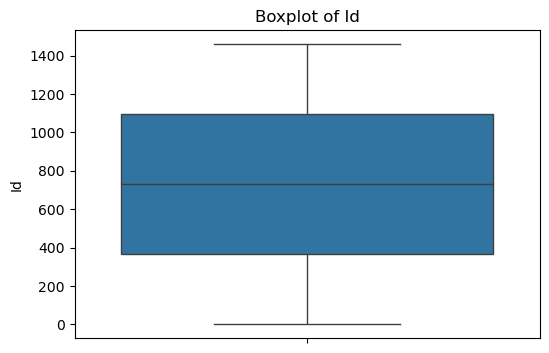

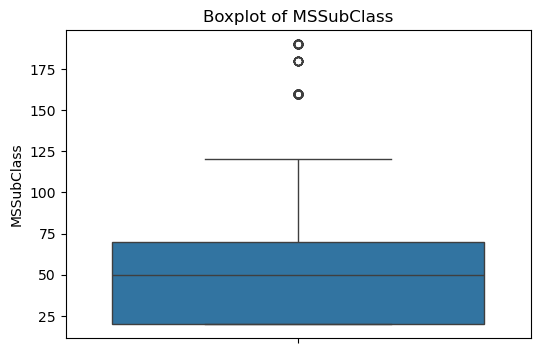

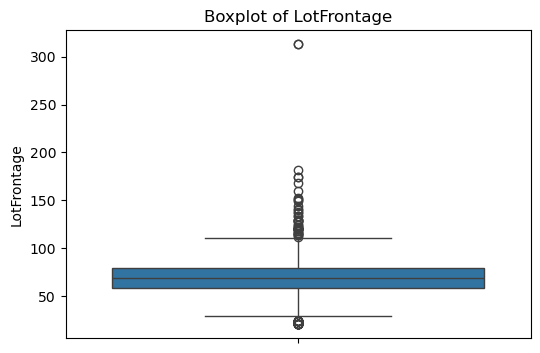

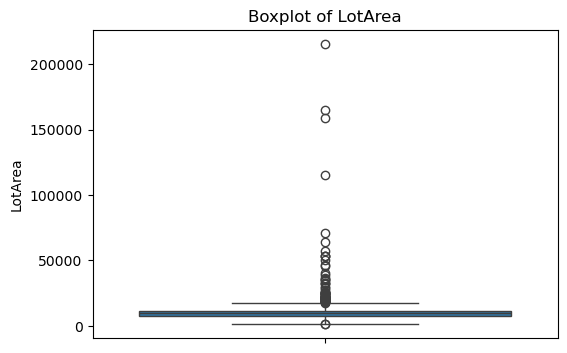

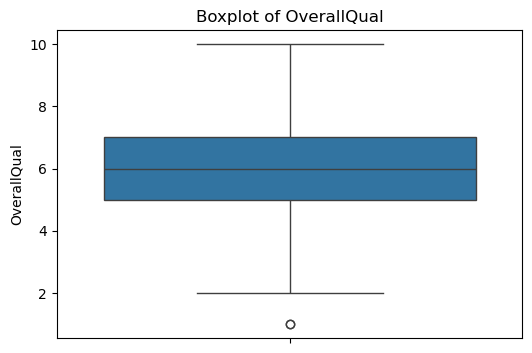

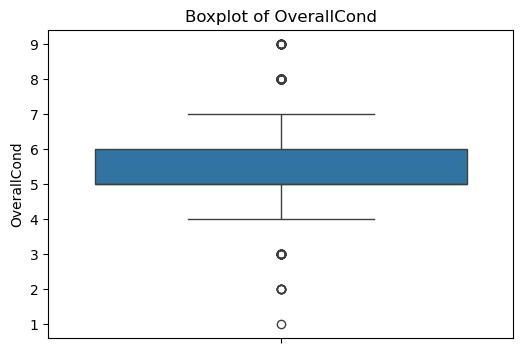

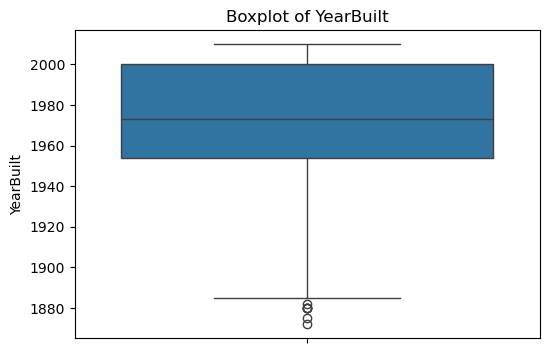

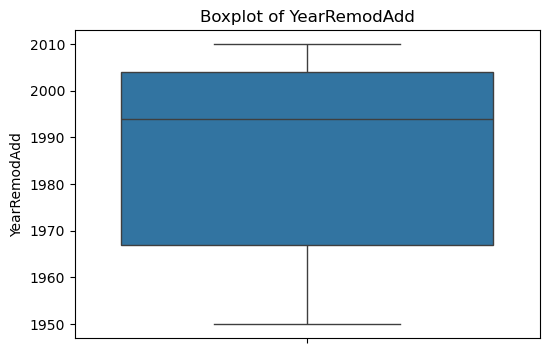

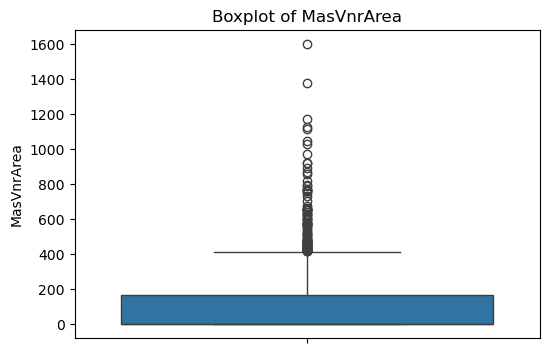

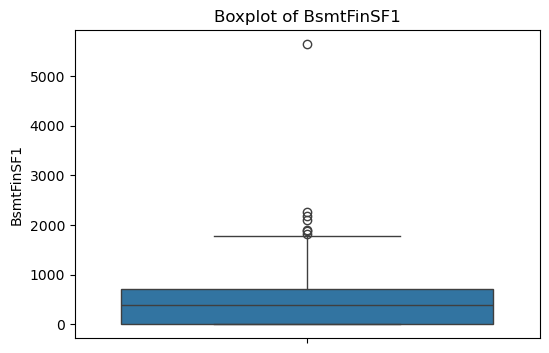

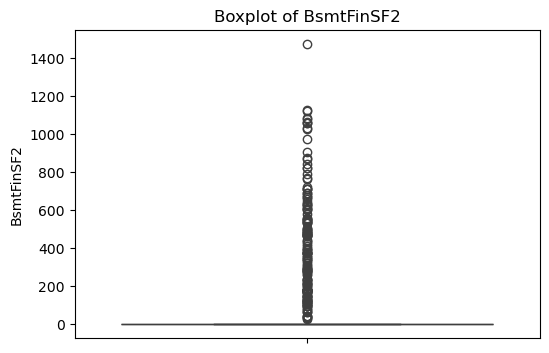

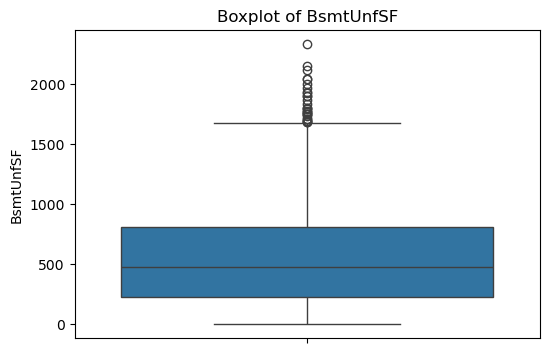

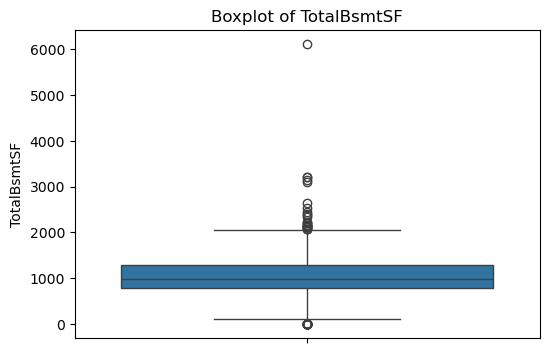

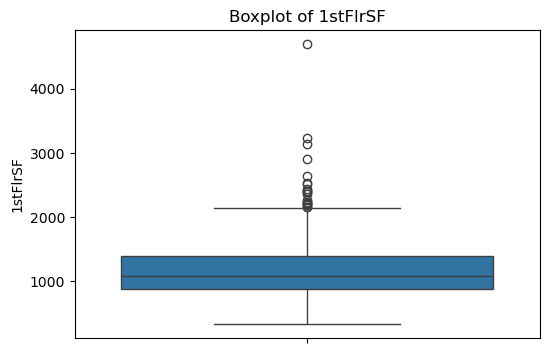

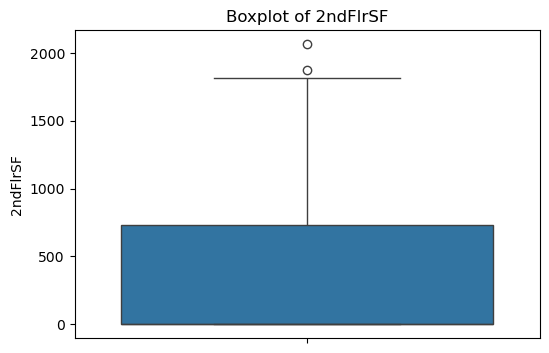

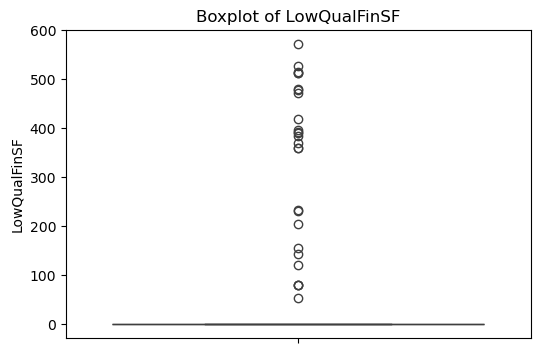

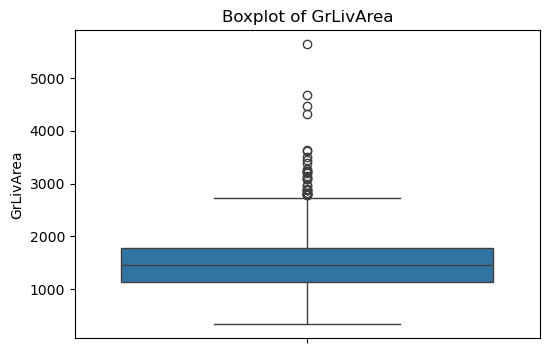

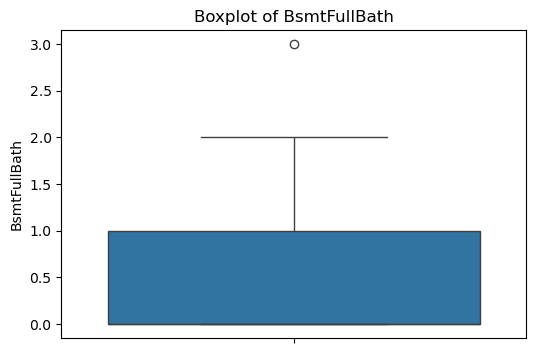

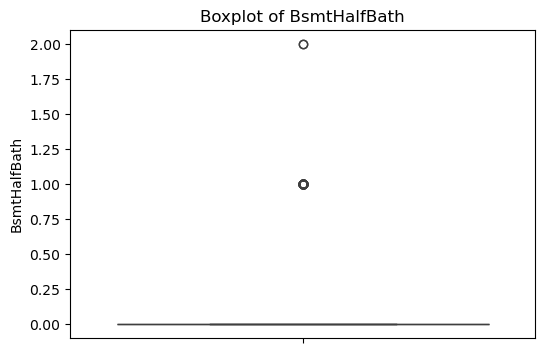

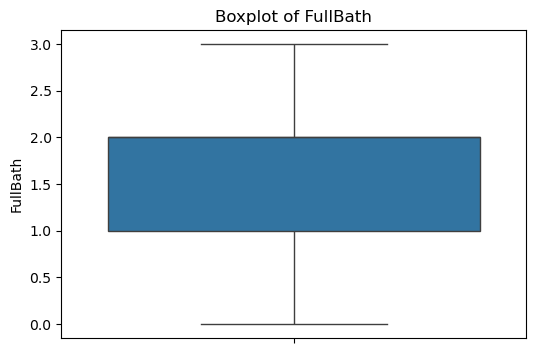

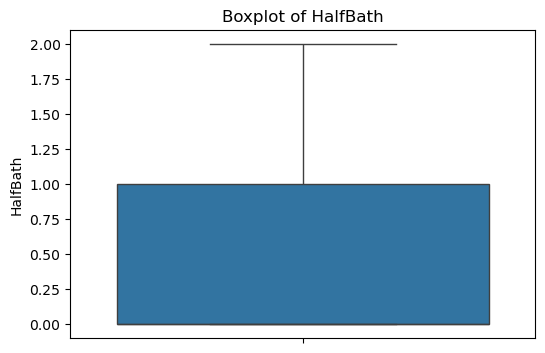

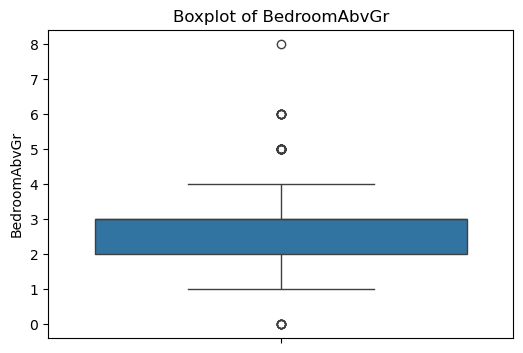

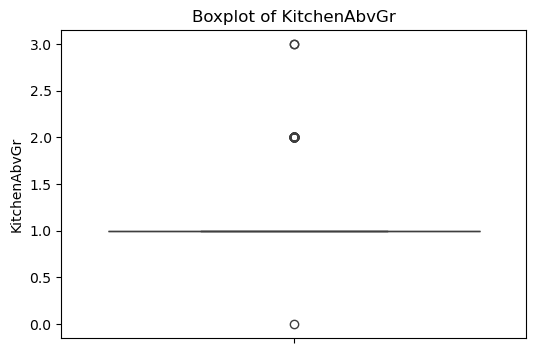

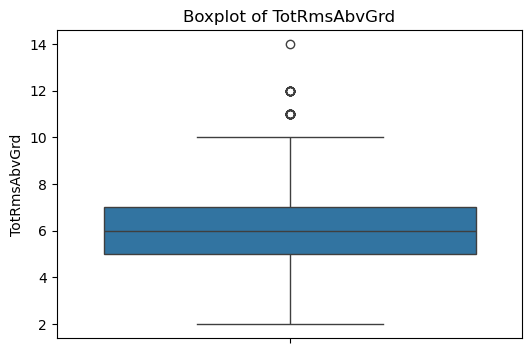

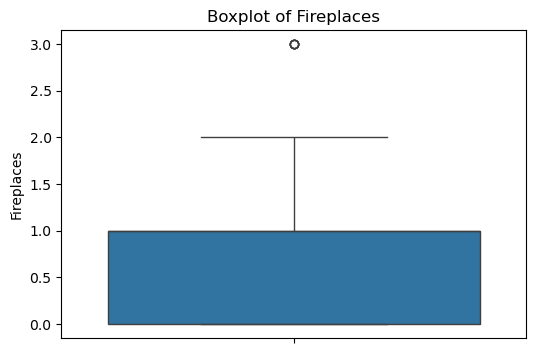

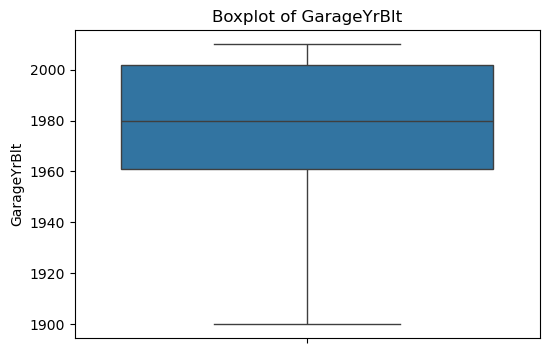

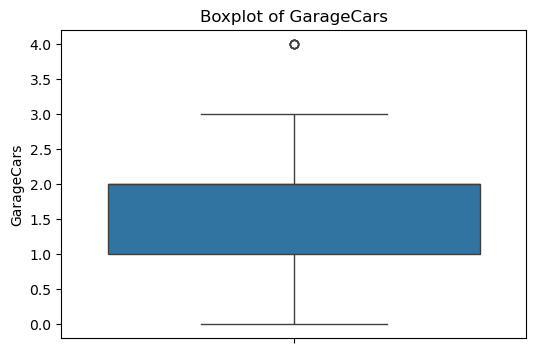

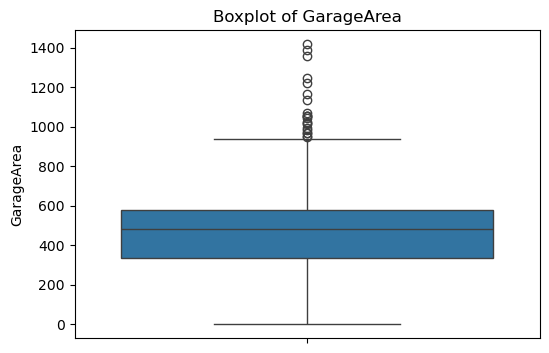

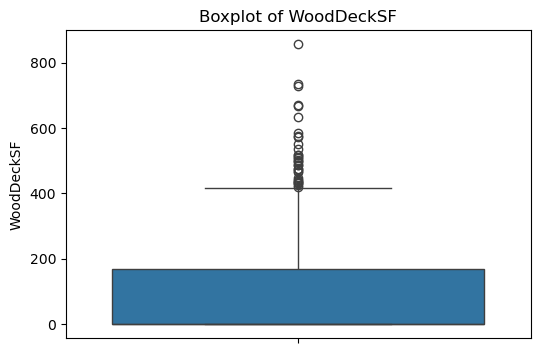

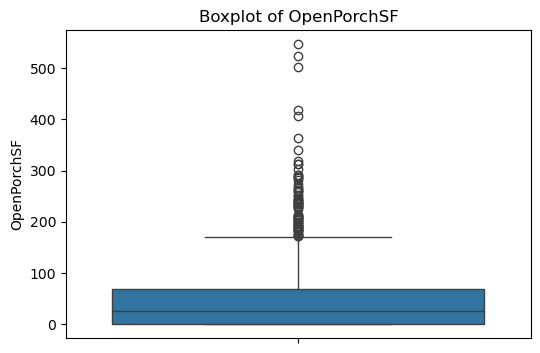

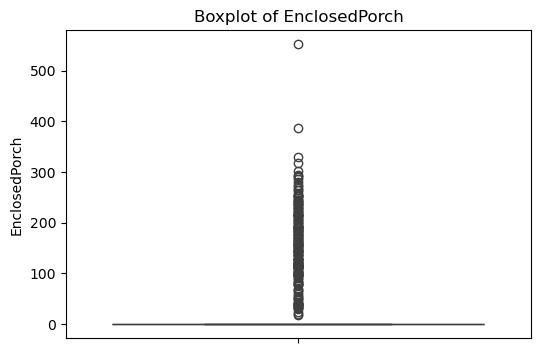

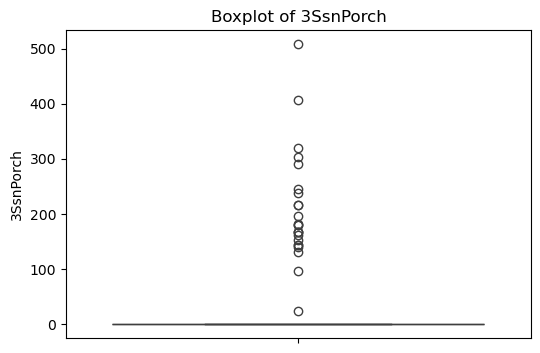

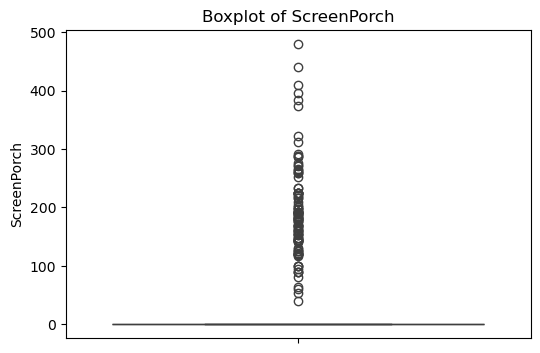

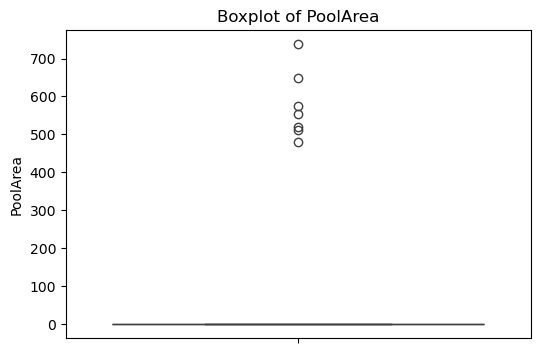

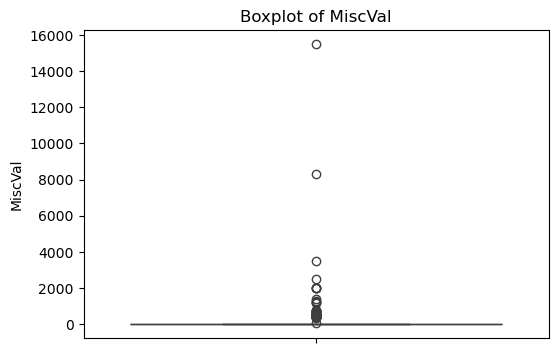

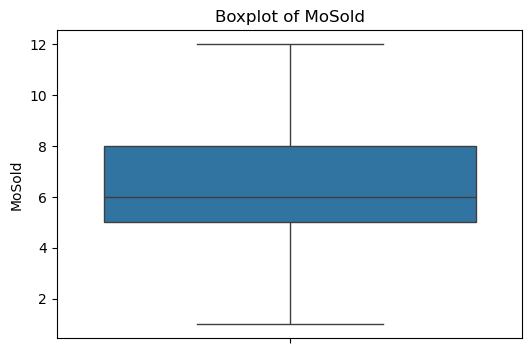

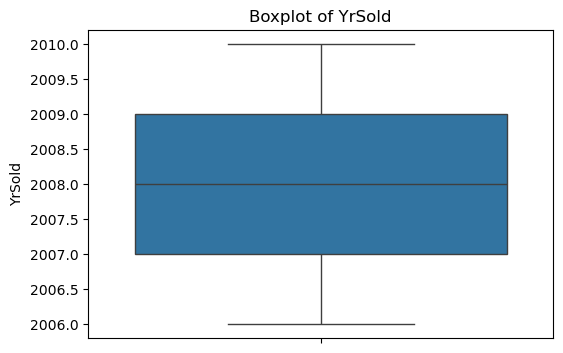

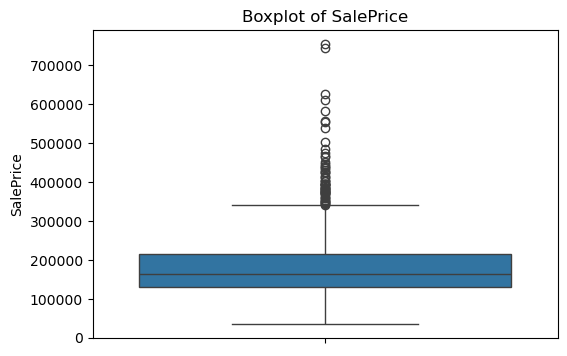

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("HouseData.csv")

# Select numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Create separate boxplots
for col in num_cols:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    
    plt.show()

Original Shape : (1460, 81)
After Outlier Removal : (423, 81)


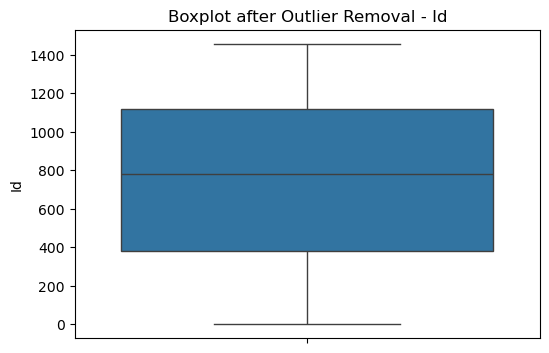

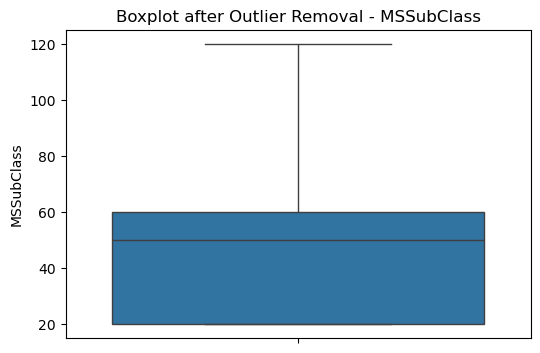

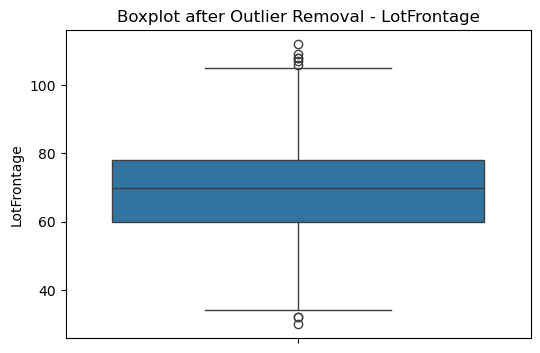

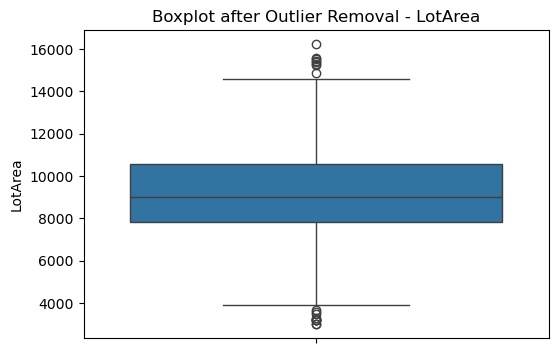

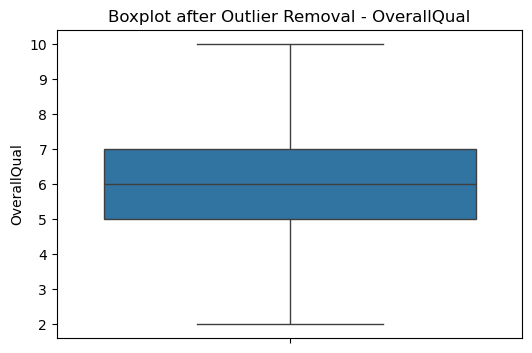

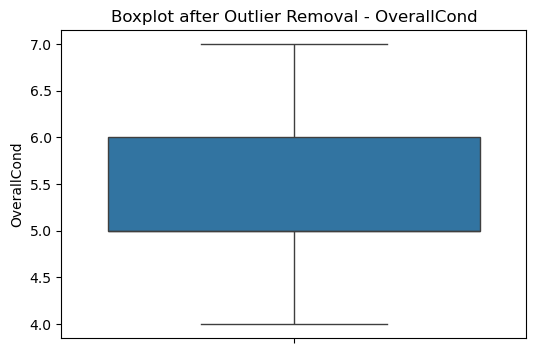

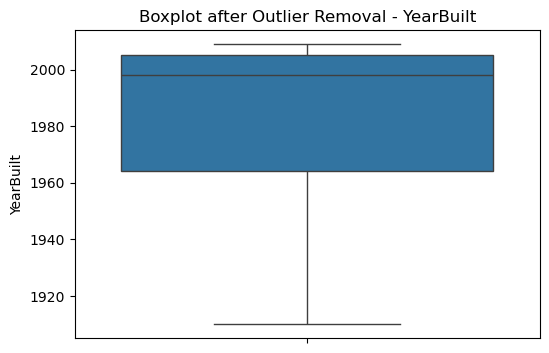

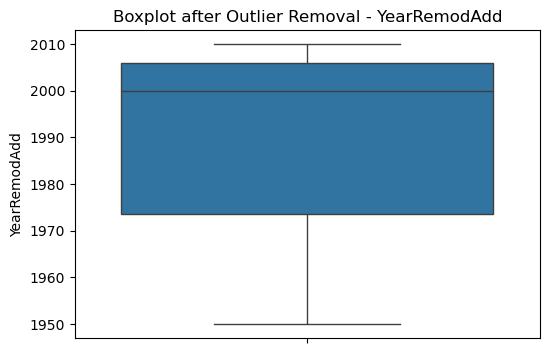

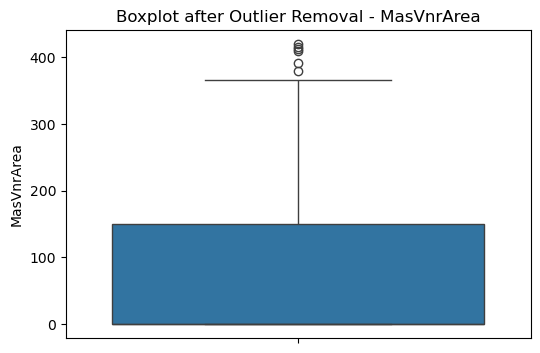

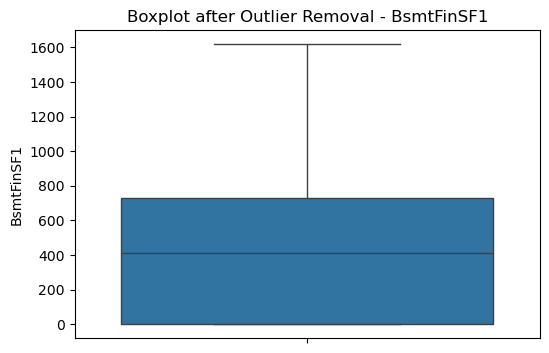

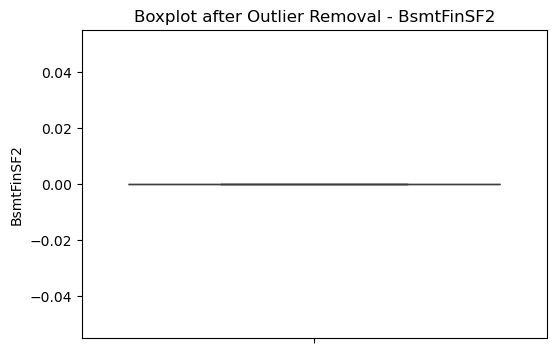

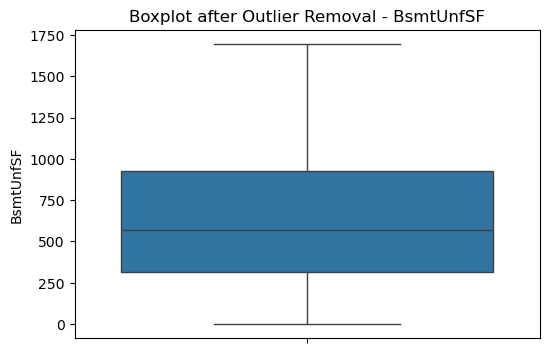

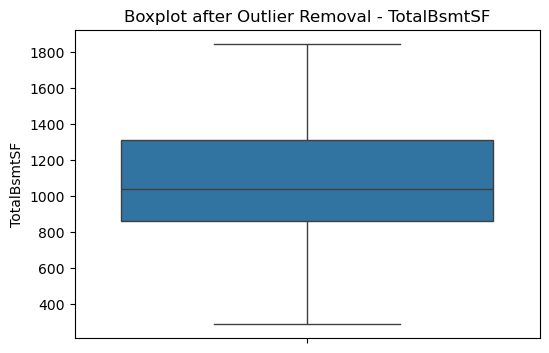

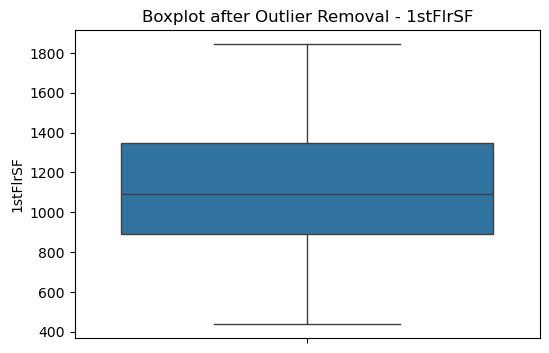

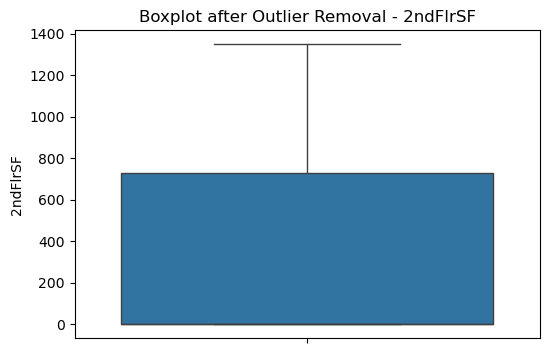

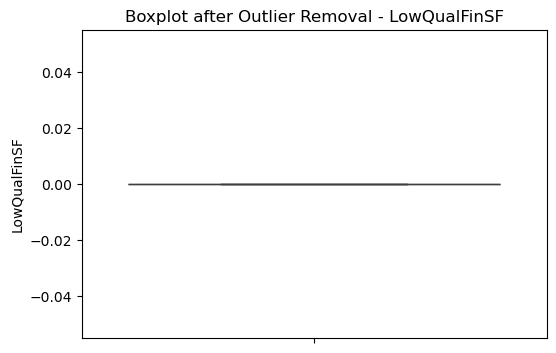

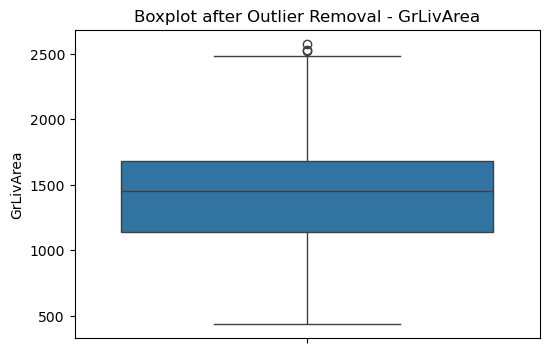

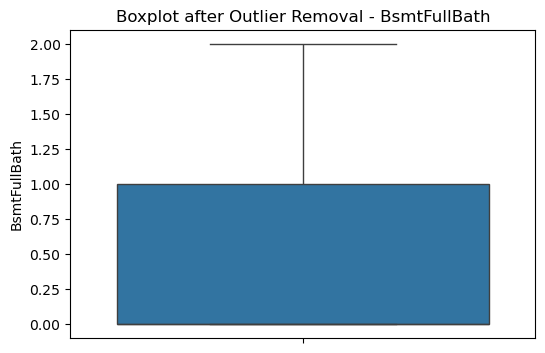

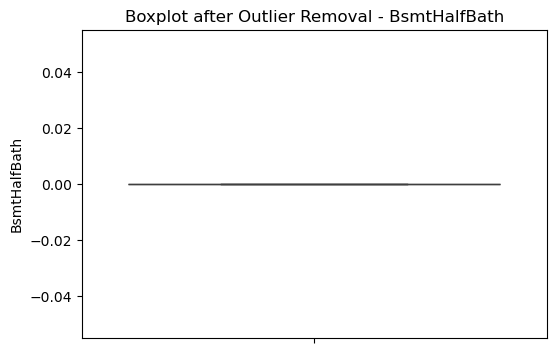

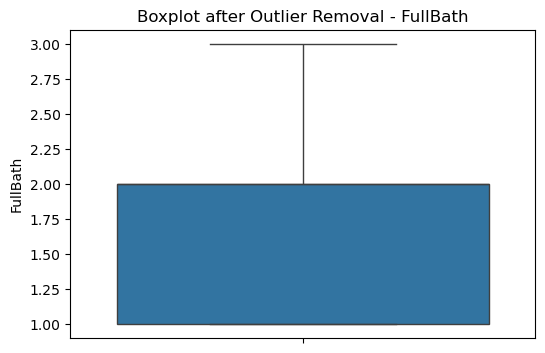

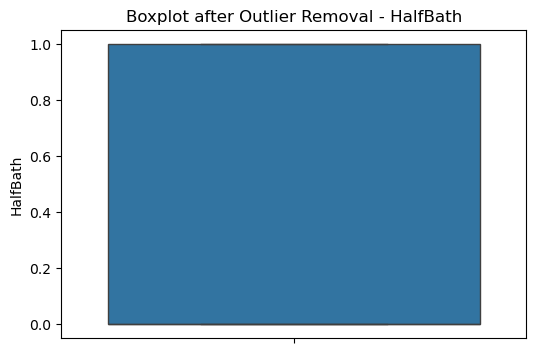

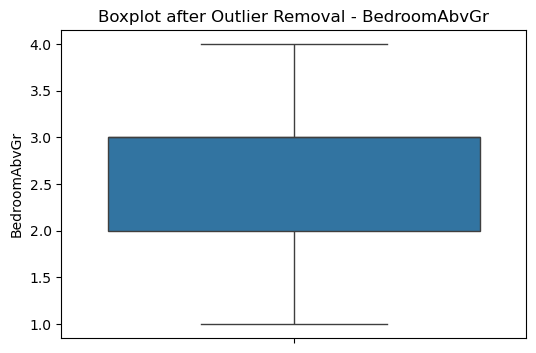

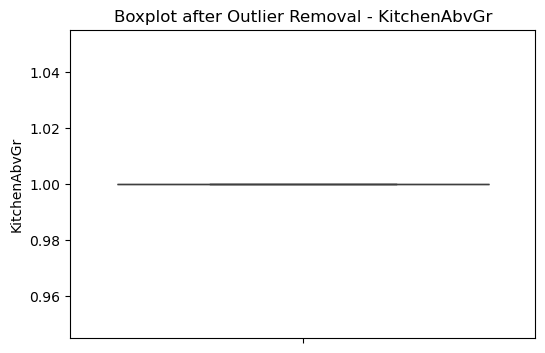

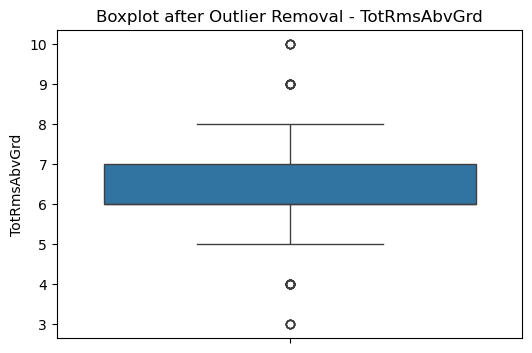

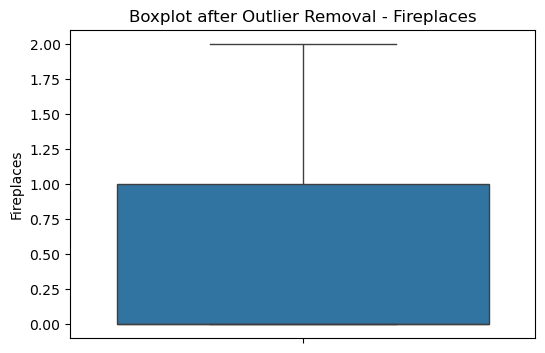

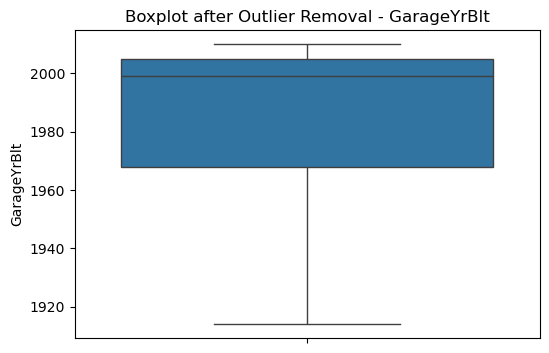

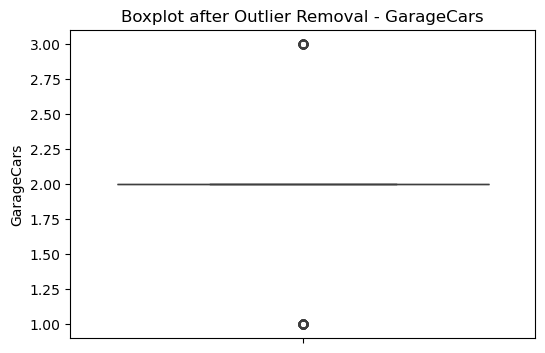

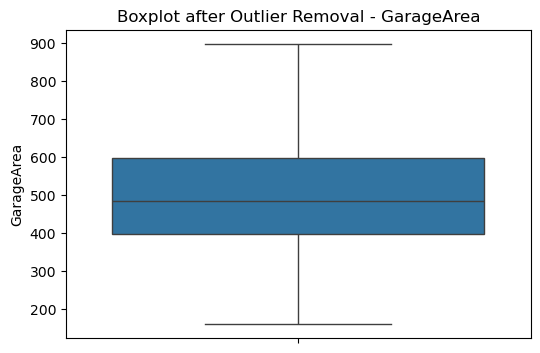

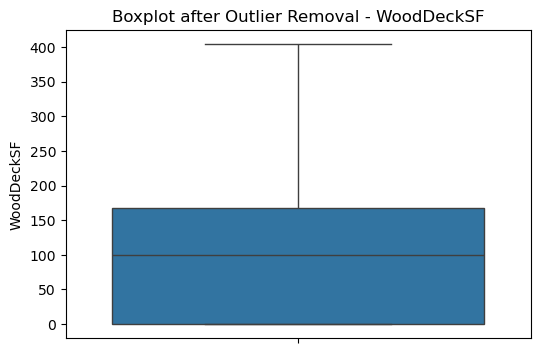

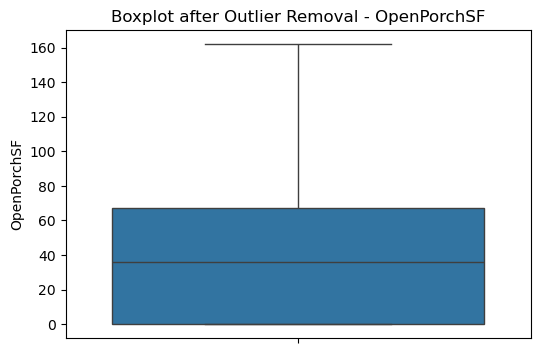

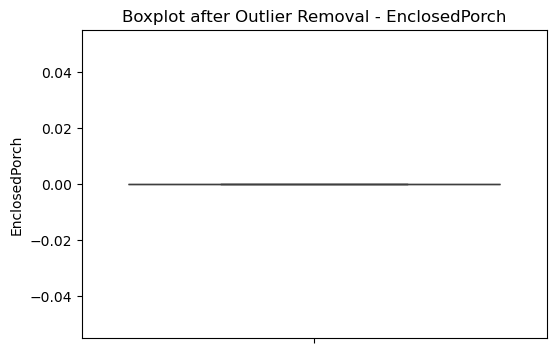

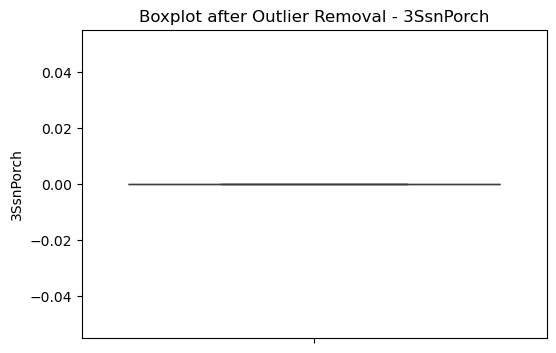

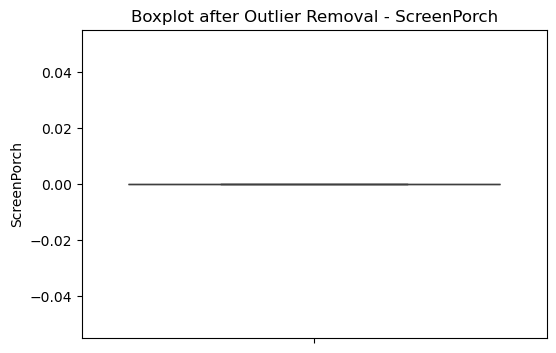

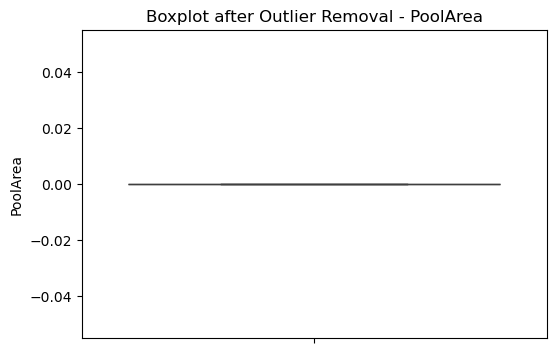

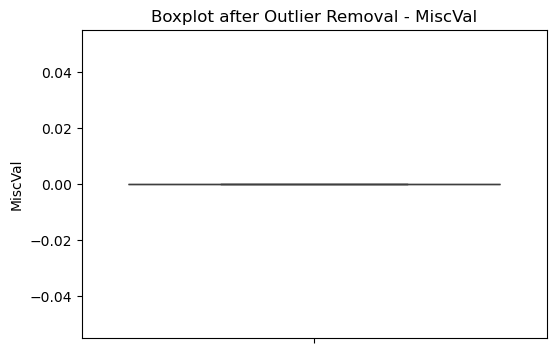

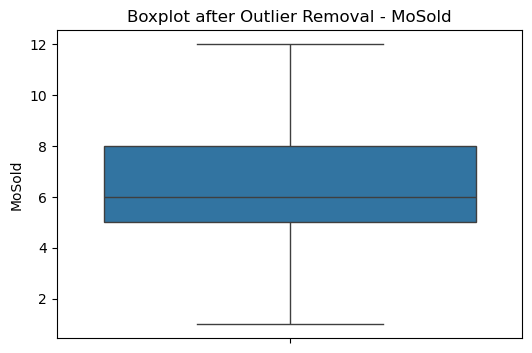

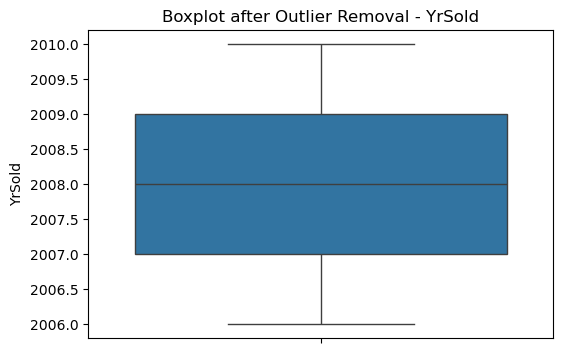

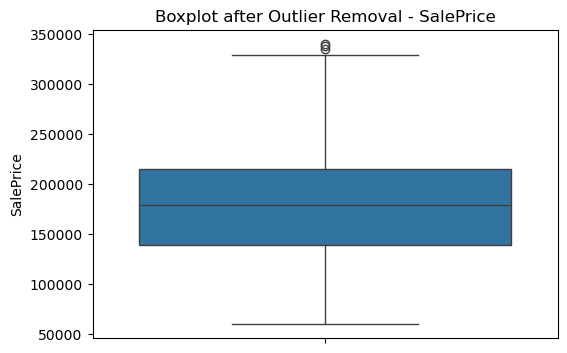

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("HouseData.csv")

num_cols = df.select_dtypes(include=['int64','float64']).columns



df_clean = df.copy()

for col in num_cols:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    df_clean = df_clean[(df_clean[col] >= lower_limit) & (df_clean[col] <= upper_limit)]

print("Original Shape :", df.shape)
print("After Outlier Removal :", df_clean.shape)




for col in num_cols:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df_clean[col])
    plt.title(f"Boxplot after Outlier Removal - {col}")
    plt.show()

In [43]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
import pandas as pd

In [45]:
x=df[['OverallQual','LotFrontage','GrLivArea','BedroomAbvGr',
'GarageArea','TotalBsmtSF','1stFlrSF',
'YearBuilt','FullBath','LotArea','YrSold','TotRmsAbvGrd']]
y=df[['SalePrice']]

In [46]:
from scipy.stats import skew,kurtosis


In [ ]:

# -------- SPLIT FEATURES AND TARGET -------- #

X = df_clean.drop("SalePrice", axis=1)   # Features
y = df_clean["SalePrice"]                # Target

# -------- TRAIN TEST SPLIT -------- #

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (338, 80)
X_test shape: (85, 80)
y_train shape: (338,)
y_test shape: (85,)


In [48]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("HouseData.csv")

# Features
X = df[['OverallQual','GrLivArea','GarageArea','TotalBsmtSF',
        '1stFlrSF','YearBuilt','LotArea','GarageCars','FullBath']]

# Target
y = df['SalePrice']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))



Accuracy Score: 0.7968968274907982
MSE: 1557867586.8601792


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("HouseData.csv")

features = [
'OverallQual','GrLivArea','GarageArea',
'TotalBsmtSF','1stFlrSF','YearBuilt',
'LotArea','GarageCars','FullBath'
]

X = df[features]
y = df['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = DecisionTreeRegressor(random_state=42)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

Accuracy Score: 0.7585831490276425
MSE: 1851745998.869863


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("HouseData.csv")

features = [
'OverallQual','GrLivArea','GarageArea',
'TotalBsmtSF','1stFlrSF','YearBuilt',
'LotArea','GarageCars','FullBath'
]

X = df[features]
y = df['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

Accuracy Score: 0.8880407867327579
MSE: 858763687.65978


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

df = pd.read_csv("HouseData.csv")

features = [
'OverallQual','GrLivArea','GarageArea',
'TotalBsmtSF','1stFlrSF','YearBuilt',
'LotArea','GarageCars','FullBath'
]

X = df[features]

y = np.log1p(df['SalePrice'])

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVR(kernel='rbf', C=100, gamma=0.01)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:", r2_score(y_test,y_pred))

Accuracy Score: 0.8573348107597055


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("HouseData.csv")

# Feature selection
features = [
'OverallQual','GrLivArea','GarageArea',
'TotalBsmtSF','1stFlrSF','YearBuilt',
'LotArea','GarageCars','FullBath'
]

X = df[features]
y = df['SalePrice']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model reference
rf_model = RandomForestRegressor(random_state=42)

# Hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid search reference
rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train model
rf_grid_search.fit(X_train, y_train)

# Best model reference
best_rf_model = rf_grid_search.best_estimator_

# Prediction
y_pred = best_rf_model.predict(X_test)

# Evaluation
print("Best Parameters:", rf_grid_search.best_params_)
print("Accuracy Score:", r2_score(y_test, y_pred))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Accuracy Score: 0.8769821856447814


In [6]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [8]:
rf_model = RandomForestRegressor()

rf_model.fit(X_train, y_train)

import joblib as jb
jb.dump(rf_model, 'SalePrice3.pkl')

['SalePrice3.pkl']

In [12]:
import joblib as jb

jb.dump(best_rf_model,'SalePrice3.pkl')

['SalePrice3.pkl']